In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import pandas as pd
import numpy as np

In [9]:
import sys
sys.path.append('../src')

In [10]:
from transformers.transformers_l import (
    DropColumnsTransformer, CityBasedImputer, CityMapTransformer,
    RollingAverageTransformer, YearTransformer, LagFeatureTransformer,
    WeekOfYearFeatureTransformer
)
# from transformers.imputation_by_city import CityBasedImputer


In [11]:
X = pd.read_csv('../src/data/raw/dengue_features_train.csv')
y = pd.read_csv('../src/data/raw/dengue_labels_train.csv')
y = y[['total_cases']]

/var/folders/qs/wdcj2f75283gh6391n4t1by80000gq/T/ipykernel_99897/3135745851.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values[1:], y=correlations.index[1:], palette=colors)


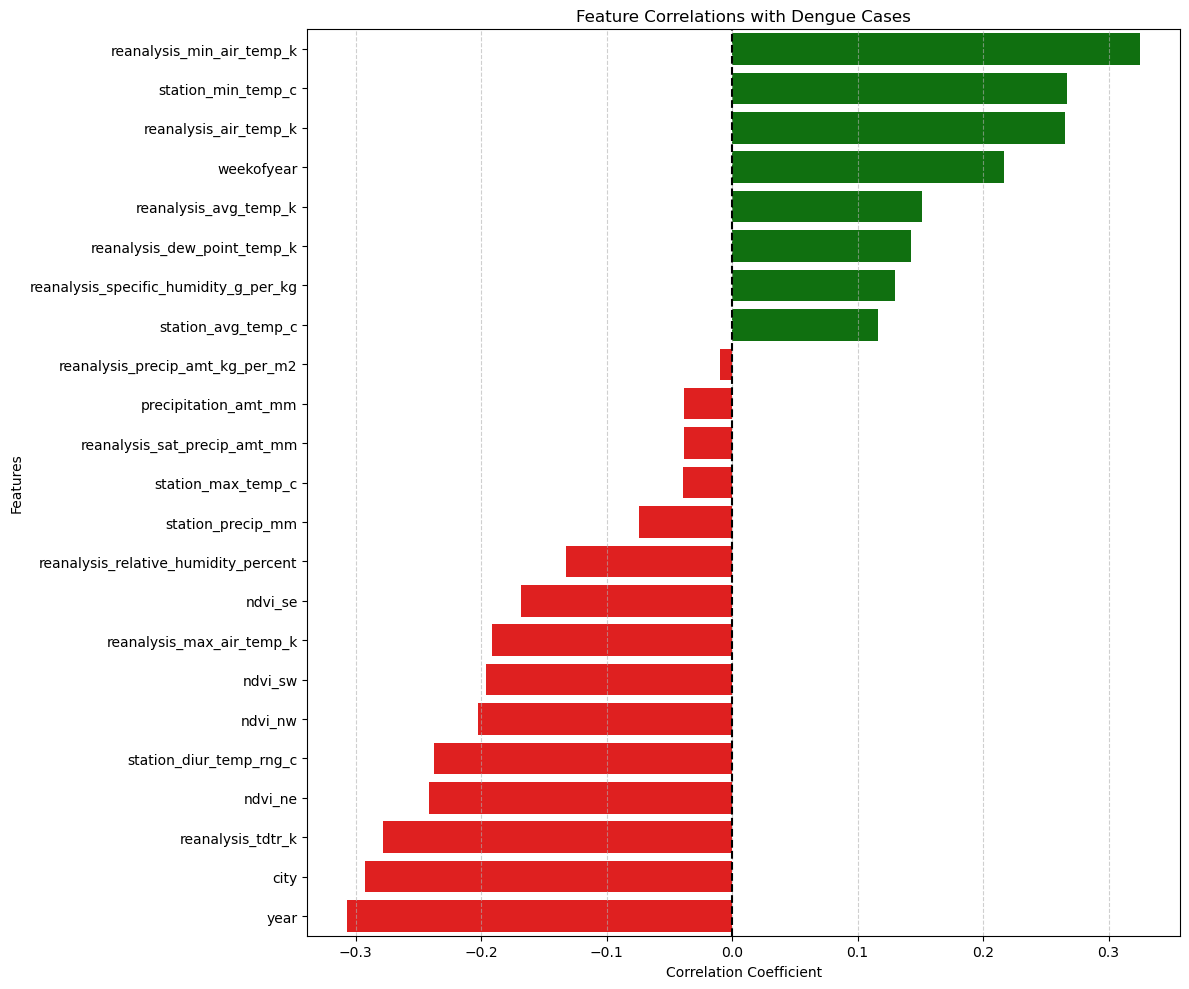

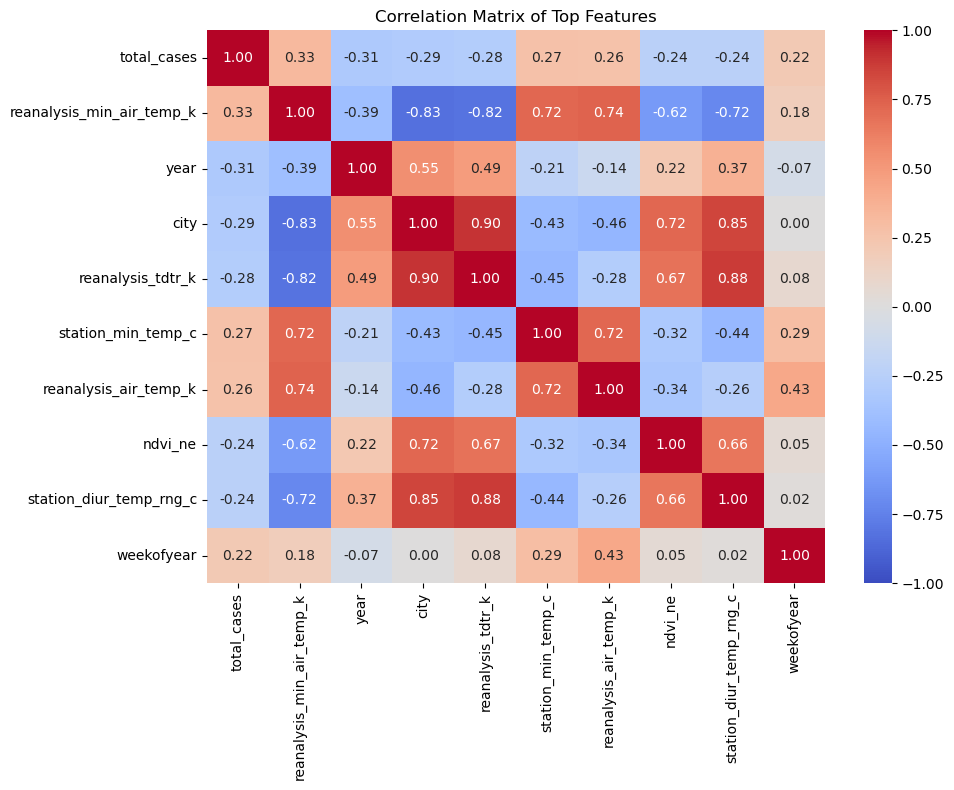

Top positively correlated features:
total_cases                  1.000000
reanalysis_min_air_temp_k    0.325252
station_min_temp_c           0.267109
reanalysis_air_temp_k        0.264952
weekofyear                   0.216452
reanalysis_avg_temp_k        0.151637
Name: total_cases, dtype: float64

Top negatively correlated features:
station_diur_temp_rng_c   -0.237844
ndvi_ne                   -0.241376
reanalysis_tdtr_k         -0.278483
city                      -0.292624
year                      -0.306806
Name: total_cases, dtype: float64


In [5]:
import seaborn as sns

# Combine X and y for correlation analysis
combined_df = X.copy()
combined_df['total_cases'] = y['total_cases']

# convert city column unique values to integers
city_map = {'sj': 0, 'iq': 1}
combined_df['city'] = combined_df['city'].map(city_map)

# Drop object columns
object_cols = combined_df.select_dtypes(include=['object']).columns
combined_df.drop(columns=object_cols, inplace=True)

# Calculate correlations with target variable
correlations = combined_df.corr()['total_cases'].sort_values(ascending=False)

# Create visualizations
import matplotlib.pyplot as plt

# Create a bar plot for all features
plt.figure(figsize=(12, 10))
colors = ['green' if x > 0 else 'red' for x in correlations.values[1:]]
sns.barplot(x=correlations.values[1:], y=correlations.index[1:], palette=colors)
plt.title('Feature Correlations with Dengue Cases')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Create a heatmap for top correlated features
# Select top correlated features (both positive and negative)
top_features = list(correlations.abs().sort_values(ascending=False).head(10).index)
plt.figure(figsize=(10, 8))
sns.heatmap(combined_df[top_features].corr(), annot=True, cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Correlation Matrix of Top Features')
plt.tight_layout()
plt.show()

# Print top correlations
print("Top positively correlated features:")
print(correlations.head(6))
print("\nTop negatively correlated features:")
print(correlations.tail(5))

In [4]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [14]:



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,
# reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,
# station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm

#create a list of k columns reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k

training_features = [
    "ndvi_ne",
    "ndvi_nw",
    "ndvi_se",
    "ndvi_sw",
    "precipitation_amt_mm",
    "reanalysis_air_temp_k",
    "reanalysis_avg_temp_k",
    "reanalysis_dew_point_temp_k",
    "reanalysis_max_air_temp_k",
    "reanalysis_min_air_temp_k",
    "reanalysis_precip_amt_kg_per_m2",
    "reanalysis_relative_humidity_percent",
    "reanalysis_sat_precip_amt_mm",
    "reanalysis_specific_humidity_g_per_kg",
    "reanalysis_tdtr_k",
    "station_avg_temp_c",
    "station_diur_temp_rng_c",
    "station_max_temp_c",
    "station_min_temp_c",
    "station_precip_mm"
]

moving_features = [
    'ndvi_ne',
    'ndvi_sw',
    'precipitation_amt_mm',
    'reanalysis_avg_temp_k',
    'reanalysis_max_air_temp_k',
    'reanalysis_min_air_temp_k',
    # 'reanalysis_precip_amt_kg_per_m2',
    'reanalysis_relative_humidity_percent',
    # 'reanalysis_specific_humidity_g_per_kg',
    'station_avg_temp_c',
    'station_diur_temp_rng_c',
    'station_max_temp_c',
    # 'station_min_temp_c',
    'station_precip_mm'
]

first_drop_columns = [
    'week_start_date', 
    'reanalysis_sat_prescip_amt_mm',
    'ndvi_nw',
    'ndvi_se',
    'reanalysis_air_temp_k',
    'reanalysis_tdtr_k',
    'reanalysis_precip_amt_kg_per_m2',
    'station_min_temp_c',
    'precipitation_amt_mm',
    'reanalysis_avg_temp_k',
]

lagging_features = [
    'reanalysis_specific_humidity_g_per_kg',
    # 'reanalysis_dew_point_temp_k',
    'reanalysis_min_air_temp_k',
    # 'station_avg_temp_c',
    # 'reanalysis_tdtr_k',
    'reanalysis_precip_amt_kg_per_m2'
    'ndvi_ne',
]

preserved_features = [
    'city',
    'year',
    'weekofyear',
]

# take the features that are not in lagging_features or preserve_features
features_to_drop = list(set(X.columns) - set(lagging_features) - set(preserved_features))

# Define the pipeline with optimized parameters
pipeline = Pipeline(steps=[
    ('drop_columns', DropColumnsTransformer(columns_to_drop=features_to_drop)),
    ('city_encoder', CityMapTransformer()),
    ('imputer', CityBasedImputer(city_column='city')),
    ('year_scaling', YearTransformer(year_col='year', base_year=1990)),
    ('drop_year', DropColumnsTransformer(columns_to_drop='year')),
    # ("city_sel", CitySelector(city=None)),
    # # 3) rolling-mean imputer per city
    # ("rolling_imp", CityWiseRollingMeanImputer(window_size=3, min_periods=1)),
    ('rolling_avg', RollingAverageTransformer(
        columns=lagging_features, 
        window=3)),
    # ('lagging_features', LagFeatureTransformer(columns=lagging_features, lag=2, city_column='city')),
    ('drop_rolling_columns', DropColumnsTransformer(columns_to_drop=lagging_features)),  # Keep this to drop original features
    ('city_onehot', ColumnTransformer([('onehot', OneHotEncoder(sparse_output=False, drop='first'), ['city'])], remainder='passthrough')), 
    ("scaler", StandardScaler()),
    # ('model', RandomForestRegressor(
    #     n_estimators=100,  # Changed from 100 to 50
    #     max_depth=None,   # Already None by default
    #     min_samples_leaf=1,  # Already 1 by default
    #     random_state=0)),
    ('model', AdaBoostRegressor(
        estimator=GradientBoostingRegressor(
            max_depth=5,
            min_samples_split=2,
            loss='squared_error',
            n_estimators=400,
            learning_rate=0.1,
            random_state=1
        ),
        n_estimators=50,  # Number of boosting stages
        learning_rate=0.1,
        random_state=1
    ))
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Calculate the mean absolute error
mean_absolute_error(y_test, y_pred)


/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


8.570561322230528

In [15]:
X_test_competition  = pd.read_csv('../src/data/raw/dengue_features_test.csv')

pipeline.fit(X, y)
predictions = pipeline.predict(X_test_competition)

# round the predictions to the nearest integer
predictions = np.round(predictions).astype(int)

# Create a DataFrame for the predictions as city,year,weekofyear,total_cases
predictions_df = pd.DataFrame({
    'city': X_test_competition['city'],
    'year': X_test_competition['year'],
    'weekofyear': X_test_competition['weekofyear'],
    'total_cases': predictions
})

# Show predictions
print(predictions_df.head())

# Save the predictions to a CSV file
predictions_df.to_csv('../src/data/predictions/baseline_prediction.csv', index=False)


/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  city  year  weekofyear  total_cases
0   sj  2008          18            3
1   sj  2008          19            4
2   sj  2008          20            5
3   sj  2008          21            5
4   sj  2008          22            4


In [9]:
from sklearn.model_selection import GridSearchCV

moving_features = [
    'ndvi_ne',
    'ndvi_sw',
    'precipitation_amt_mm',
    'reanalysis_avg_temp_k',
    'reanalysis_max_air_temp_k',
    'reanalysis_min_air_temp_k',
    # 'reanalysis_precip_amt_kg_per_m2',
    'reanalysis_relative_humidity_percent',
    # 'reanalysis_specific_humidity_g_per_kg',
    'station_avg_temp_c',
    'station_diur_temp_rng_c',
    'station_max_temp_c',
    # 'station_min_temp_c',
    'station_precip_mm'
]

second_drop_columns = [
    'reanalysis_precip_amt_kg_per_m2',
    'station_min_temp_c',
 ]

# Define the pipeline without the final estimator
pipeline_without_model = Pipeline(steps=[
        ('drop_columns', DropColumnsTransformer(columns_to_drop=[
                     'week_start_date', 
                     'reanalysis_sat_prescip_amt_mm',
                     'reanalysis_dew_point_temp_k',
                     'ndvi_nw',
                     'ndvi_se',
                     'reanalysis_air_temp_k',
                     'reanalysis_tdtr_k'])),
    ('city_encoder', CityMapTransformer()),
    ('imputer', CityBasedImputer(city_column='city')),
    ('rolling_avg', RollingAverageTransformer(
        columns=moving_features, 
        window=3)),
    ('drop_rolling_columns', DropColumnsTransformer(columns_to_drop=moving_features)),
    ('drop_extra_columns', DropColumnsTransformer(columns_to_drop=second_drop_columns)),
    ('city_onehot', ColumnTransformer([('onehot', OneHotEncoder(sparse_output=False, drop='first'), ['city'])], remainder='passthrough'))
])

# Define parameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3, 5]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=0),
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

# Prepare the data with the pipeline
X_train_transformed = pipeline_without_model.fit_transform(X_train)
X_test_transformed = pipeline_without_model.transform(X_test)

# Fit GridSearchCV
grid_search.fit(X_train_transformed, y_train)

# Print results
print(f"Best n_estimators: {grid_search.best_params_['n_estimators']}")
print(f"Best MAE score: {-grid_search.best_score_:.2f}")

# Use the best model for predictions
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_transformed)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE with best model: {mae:.2f}")

# Create the final pipeline with the best estimator for later use
final_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline_without_model),
    ('model', best_rf)
])

Fitting 5 folds for each of 45 candidates, totalling 225 fits


/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/dsr_challenge-env/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vec

KeyboardInterrupt: 

In [ ]:
print(f"Best parameters: {grid_search}")

Best parameters: GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 3, 5],
                         'n_estimators': [50, 100, 200, 300, 500]},
             scoring='neg_mean_absolute_error', verbose=1)
